# 04 Assignment – Encoder-Decoder mit Attention (Seq2Seq) & Brücke zu Transformern

Bern University of Applied Sciences – CAS AI HS 25  
Dozent: Ilja Rasin  

Dieses Notebook gehört zur vierten Vorlesung (Transformer & Attention).

**Ziele der Einheit**

- Wiederholung: LSTM als Baustein für Sequenzmodelle  
- Encoder-Decoder-Architektur (Seq2Seq) verstehen  
- Dot-Product-Attention auf Basis von LSTM implementieren  
- Attention-Gewichte visualisieren (Heatmap)  
- Einen ersten Blick auf "große" Transformer-Modelle mit Hugging Face werfen

## 1. Imports & Setup

In [ ]:

import math
import random
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 2. Mini-Datensatz: einfache “Übersetzung”

In [ ]:
# Einfache Beispielsätze: Deutsch -> Englisch
pairs = [
    ("eins zwei drei", "one two three"),
    ("vier fünf", "four five"),
    ("eins zwei", "one two"),
    ("drei vier fünf", "three four five"),
    ("wir lieben pytorch", "we love pytorch"),
    ("ich lerne ki", "i learn ai"),
]

# Wir fügen zusätzlich ein paar Zufallsvarianten auf Basis der Zahlen ein
de_numbers = ["eins", "zwei", "drei", "vier", "fünf"]
en_numbers = ["one", "two", "three", "four", "five"]

for _ in range(20):
    length = random.randint(2, 4)
    idxs = [random.randint(0, 4) for _ in range(length)]
    src = " ".join(de_numbers[i] for i in idxs)
    trg = " ".join(en_numbers[i] for i in idxs)
    pairs.append((src, trg))

len(pairs), pairs[:10]


(26,
 [('eins zwei drei', 'one two three'),
  ('vier fünf', 'four five'),
  ('eins zwei', 'one two'),
  ('drei vier fünf', 'three four five'),
  ('wir lieben pytorch', 'we love pytorch'),
  ('ich lerne ki', 'i learn ai'),
  ('eins eins drei zwei', 'one one three two'),
  ('zwei eins', 'two one'),
  ('fünf eins fünf vier', 'five one five four'),
  ('eins eins', 'one one')])

## 3. Vokabular & Tokenisierung

### Ausführliche Erklärung

itos steht für index-to-string.
Das heißt: Wenn wir einen Index haben, können wir damit das entsprechende Wort (Token) nachschlagen.

Beim Aufbau des Vokabulars (build_vocab) erzeugen wir eine Liste aller Tokens, die die Reihenfolge festlegt.

Diese Liste sieht z. B. so aus:
```
itos = [
    "<pad>",    # Index 0
    "<sos>",    # Index 1
    "<eos>",    # Index 2
    "drei",     # Index 3
    "eins",     # Index 4
    "fünf",     # Index 5
    "vier",     # Index 6
    "zwei"      # Index 7
]
```

Damit wird klar:

```itos[0] == "<pad>"```
Das Token <pad> (“Padding”) hat den Index 0.
Es wird verwendet, um Sequenzen auf gleiche Länge zu bringen.

```itos[1] == "<sos>"```
<sos> (“start of sequence”) hat den Index 1.
Der Decoder beginnt die Generierung immer mit diesem Token.

```itos[2] == "<eos>"```
<eos> (“end of sequence”) hat den Index 2.
Sobald der Decoder dieses Token ausgibt, ist der Satz beendet.

```itos[3] == "drei"```
Das tatsächliche Wort „drei“ bekommt den Index 3.
Es ist das erste „echte“ Wort im Vokabular nach den drei Spezial-Tokens.

**Warum genau in dieser Reihenfolge?**

Die drei Sondertokens haben immer feste Plätze (0, 1, 2).
Das macht Training und Paddings logischer und reproduzierbar.

Alle anderen Wörter (z. B. „drei“, „eins“, „zwei“ …) werden alphabetisch sortiert eingefügt.
Das hat keinen Einfluss auf das Lernen, sorgt aber dafür, dass das Vokabular jedes Mal im selben Aufbau entsteht.

In [ ]:
# Spezielle Tokens

# "<pad>" — padding token
# "<sos>" — start-of-sequence
# "<eos>" — end-of-sequence
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def build_vocab(sentences: List[str]):
    tokens = set()
    for s in sentences:
        tokens.update(s.split())

    # itos — index-to-string
    itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + sorted(tokens)
    print("itos: ", itos)

    # itos[0] == "<pad>"
    # itos[1] == "<sos>"
    # itos[2] == "<eos>"
    # itos[3] == "drei"

    stoi = {tok: i for i, tok in enumerate(itos)}
    print("stoi: ", stoi)
    return stoi, itos

src_sentences = [p[0] for p in pairs]
trg_sentences = [p[1] for p in pairs]

src_stoi, src_itos = build_vocab(src_sentences)
trg_stoi, trg_itos = build_vocab(trg_sentences)

SRC_VOCAB_SIZE = len(src_itos)
TRG_VOCAB_SIZE = len(trg_itos)

SRC_VOCAB_SIZE, TRG_VOCAB_SIZE, src_itos, trg_itos


itos:  ['<pad>', '<sos>', '<eos>', 'drei', 'eins', 'fünf', 'ich', 'ki', 'lerne', 'lieben', 'pytorch', 'vier', 'wir', 'zwei']
stoi:  {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'drei': 3, 'eins': 4, 'fünf': 5, 'ich': 6, 'ki': 7, 'lerne': 8, 'lieben': 9, 'pytorch': 10, 'vier': 11, 'wir': 12, 'zwei': 13}
itos:  ['<pad>', '<sos>', '<eos>', 'ai', 'five', 'four', 'i', 'learn', 'love', 'one', 'pytorch', 'three', 'two', 'we']
stoi:  {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'ai': 3, 'five': 4, 'four': 5, 'i': 6, 'learn': 7, 'love': 8, 'one': 9, 'pytorch': 10, 'three': 11, 'two': 12, 'we': 13}


(14,
 14,
 ['<pad>',
  '<sos>',
  '<eos>',
  'drei',
  'eins',
  'fünf',
  'ich',
  'ki',
  'lerne',
  'lieben',
  'pytorch',
  'vier',
  'wir',
  'zwei'],
 ['<pad>',
  '<sos>',
  '<eos>',
  'ai',
  'five',
  'four',
  'i',
  'learn',
  'love',
  'one',
  'pytorch',
  'three',
  'two',
  'we'])

In [ ]:
def encode_sentence(sentence: str, stoi: dict, add_sos_eos: bool = True):
    tokens = sentence.split()
    ids = [stoi[t] for t in tokens]
    if add_sos_eos:
        ids = [stoi[SOS_TOKEN]] + ids + [stoi[EOS_TOKEN]]
    return ids

max_len_src = max(len(encode_sentence(s, src_stoi)) for s in src_sentences)
max_len_trg = max(len(encode_sentence(s, trg_stoi)) for s in trg_sentences)
max_len_src, max_len_trg


(6, 6)

In [ ]:
for s in src_sentences:
  encoded_ids = encode_sentence(s, src_stoi)
  print(s, encoded_ids)

eins zwei drei [1, 4, 13, 3, 2]
vier fünf [1, 11, 5, 2]
eins zwei [1, 4, 13, 2]
drei vier fünf [1, 3, 11, 5, 2]
wir lieben pytorch [1, 12, 9, 10, 2]
ich lerne ki [1, 6, 8, 7, 2]
eins eins drei zwei [1, 4, 4, 3, 13, 2]
zwei eins [1, 13, 4, 2]
fünf eins fünf vier [1, 5, 4, 5, 11, 2]
eins eins [1, 4, 4, 2]
zwei fünf [1, 13, 5, 2]
eins fünf zwei fünf [1, 4, 5, 13, 5, 2]
zwei vier fünf [1, 13, 11, 5, 2]
eins zwei vier [1, 4, 13, 11, 2]
drei zwei zwei [1, 3, 13, 13, 2]
eins eins vier [1, 4, 4, 11, 2]
drei drei [1, 3, 3, 2]
drei eins vier fünf [1, 3, 4, 11, 5, 2]
vier eins [1, 11, 4, 2]
drei fünf drei fünf [1, 3, 5, 3, 5, 2]
eins eins [1, 4, 4, 2]
zwei drei eins zwei [1, 13, 3, 4, 13, 2]
vier drei [1, 11, 3, 2]
drei zwei drei [1, 3, 13, 3, 2]
zwei drei eins [1, 13, 3, 4, 2]
zwei fünf zwei zwei [1, 13, 5, 13, 13, 2]


In [ ]:
def pad_sequence(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    return seq + [pad_idx] * (max_len - len(seq))

PAD_IDX_TRG = trg_stoi[PAD_TOKEN]
PAD_IDX_SRC = src_stoi[PAD_TOKEN]

dataset = []
for src, trg in pairs:
    src_ids = encode_sentence(src, src_stoi)
    trg_ids = encode_sentence(trg, trg_stoi)
    src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
    trg_ids = pad_sequence(trg_ids, max_len_trg, PAD_IDX_TRG)
    dataset.append((src_ids, trg_ids))

len(dataset), dataset[0]


(26, ([1, 4, 13, 3, 2, 0], [1, 9, 12, 11, 2, 0]))

In [ ]:
# Mini-Dataloader

def batchify(dataset, batch_size: int):
    random.shuffle(dataset)
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        src_batch = torch.tensor([b[0] for b in batch], dtype=torch.long, device=device)
        trg_batch = torch.tensor([b[1] for b in batch], dtype=torch.long, device=device)
        yield src_batch, trg_batch


## 4. Encoder-Decoder ohne Attention

### Encoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX_SRC)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        # src: [B, src_len]
        embedded = self.embedding(src)           # [B, src_len, emb_dim]
        outputs, (hidden, cell) = self.lstm(embedded)  # outputs: [B, src_len, H]
        return outputs, (hidden, cell)


### Decoder ohne Attention

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden, cell):
        # input: [B] (aktuelles Token-Index)
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: [B, 1, H]
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell


## 5. Seq2Seq Wrapper

## Wie funktioniert ein Seq2Seq-Modell?
**Encoder**

- erhält die gesamte Eingabesequenz (**[eins, zwei, drei])**
- verarbeitet sie tokenweise (LSTM-Zeitdimension)
- erzeugt einen „Kontextvektor“ (hidden, cell)
- dieser Kontext repräsentiert die **Bedeutung** des ganzen Satzes

**Decoder**

- bekommt nicht die Eingabewörter
- bekommt nur den Kontext + \<sos> als Startsignal
- generiert das Zielsatz Wort für Wort

**Beispiel**:

- Source: "eins zwei drei"
- Target: "one two three"


Decoder erzeugt:

\<sos> → one
one → two
two → three
three → \<eos>


Er versucht nicht, "eins" zu rekonstruieren.
Er versucht, die Zielsequenz zu generieren.

### Seq2Seq-Klasse – ausführliche Erklärung

Der folgende Code implementiert den kompletten Ablauf eines Encoder-Decoder-Modells (Seq2Seq):
```
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg
```

Was passiert hier?

**encoder**: verarbeitet den Eingabesatz

**decoder**: generiert den Ausgabesatz

**trg_sos_idx**: Index des <sos>-Tokens

**trg_eos_idx**: Index des <eos>-Tokens

**max_len_trg**: maximale Länge der Zielsequenz

```
def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
    batch_size = src.size(0)
    trg_len = self.max_len_trg
    trg_vocab_size = self.decoder.fc_out.out_features
```

**Bedeutung**:

**batch_size**: Anzahl der Sätze im Batch

**trg_len**: wie viele Schritte der Decoder generieren soll

**trg_vocab_size**: Größe des Zielvokabulars (für Softmax)

outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)


**Wir erzeugen eine große Ausgabe-Matrix, in der der Decoder seine Vorhersagen ablegt:**
```
Form:
[Batch, Zeit, Vokabulargröße]

encoder_outputs, (hidden, cell) = self.encoder(src)
```


**Der Encoder liefert:**

encoder_outputs: alle LSTM-Outputs (für Attention)

hidden, cell: letzter versteckter Zustand — initialer Zustand des Decoders
```
input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)
```


**Der Decoder startet immer mit dem <sos>-Token.**

Hauptschleife
```
for t in range(trg_len):
    output, hidden, cell = self.decoder(input, hidden, cell)
    outputs[:, t, :] = output
```


Der Decoder arbeitet Schritt für Schritt:

1. erhält das aktuelle Token

2. aktualisiert seinen Zustand

3. produziert eine Wahrscheinlichkeitsverteilung über das Vokabular. Diese speichern wir in outputs

**Teacher Forcing**
```
if trg is not None and random.random() < teacher_forcing_ratio:
    input = trg[:, t]  # das echte Token
else:
    input = output.argmax(dim=1)  # das vorhergesagte Token
```

**Teacher Forcing: schnelleres Lernen**

Ohne Teacher Forcing: Modell lernt, selbstständig zu generieren

Rückgabe
```
return outputs
```

Ein Tensor der Form:
```
[Batch, Sequenzlänge, Vokabulargröße]
```

### Teacher Forcing – Erklärung auf Deutsch für Studierende

Teacher Forcing ist eine Trainingsstrategie im Decoder eines Seq2Seq-Modells.

Bei jedem Zeitschritt entscheidet das Modell:

Soll ich das nächste Wort anhand des korrekten Trainingstokens erzeugen
oder anhand meines eigenen vorherigen Outputs?

- Mit Teacher Forcing

Der Decoder erhält das richtige Wort aus der Zielsequenz.
Dadurch lernt er schneller und sammelt keine Fehler auf.

- Ohne Teacher Forcing

Der Decoder erhält sein eigenes vorhergesagtes Wort.
Das ist wichtig, um später autonom Sätze zu generieren.

> **Problem ohne Teacher Forcing**

Wenn der Decoder früh einen Fehler macht, baut sich dieser Fehler auf —
die gesamte Ausgabe kann kollabieren.

> **Lösung**

Wir mischen beides, z. B. teacher_forcing_ratio = 0.5:

if random.random() < teacher_forcing_ratio:
    input = target_token     # richtiges Token
else:
    input = predicted_token  # Modellvorhersage


So lernt der Decoder korrekt zu folgen aber auch selbstständig zu generieren

Das ergibt robustes Seq2Seq-Verhalten.

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs


## Model + Loss

In [ ]:
EMB_DIM = 32
HID_DIM = 64

encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder = Decoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model = Seq2Seq(
    encoder,
    decoder,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


## Training (erstmal ohne Attention)

In [ ]:
def train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer.zero_grad()
        outputs = model(src_batch, trg_batch, teacher_forcing_ratio)
        # outputs: [B, T, V]
        B, T, V = outputs.shape
        loss = criterion(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(50):
    loss = train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"Epoch {epoch+1}: loss={loss:.3f}")


Epoch 1: loss=2.055
Epoch 2: loss=2.036
Epoch 3: loss=1.848
Epoch 4: loss=1.846
Epoch 5: loss=1.773
Epoch 6: loss=1.714
Epoch 7: loss=1.744
Epoch 8: loss=1.805
Epoch 9: loss=1.614
Epoch 10: loss=1.593
Epoch 11: loss=1.528
Epoch 12: loss=1.561
Epoch 13: loss=1.476
Epoch 14: loss=1.579
Epoch 15: loss=1.376
Epoch 16: loss=1.429
Epoch 17: loss=1.353
Epoch 18: loss=1.310
Epoch 19: loss=1.296
Epoch 20: loss=1.141
Epoch 21: loss=1.178
Epoch 22: loss=1.182
Epoch 23: loss=1.152
Epoch 24: loss=1.257
Epoch 25: loss=1.014
Epoch 26: loss=1.132
Epoch 27: loss=1.003
Epoch 28: loss=0.965
Epoch 29: loss=1.019
Epoch 30: loss=0.878
Epoch 31: loss=0.903
Epoch 32: loss=0.964
Epoch 33: loss=0.782
Epoch 34: loss=0.910
Epoch 35: loss=0.791
Epoch 36: loss=0.793
Epoch 37: loss=0.785
Epoch 38: loss=0.753
Epoch 39: loss=0.731
Epoch 40: loss=0.755
Epoch 41: loss=0.677
Epoch 42: loss=0.641
Epoch 43: loss=0.659
Epoch 44: loss=0.636
Epoch 45: loss=0.663
Epoch 46: loss=0.588
Epoch 47: loss=0.573
Epoch 48: loss=0.543
E

## Eine Funktion zur Generierung

In [ ]:
def indices_to_sentence(indices: List[int], itos: List[str]):
    tokens = []
    for idx in indices:
        tok = itos[idx]
        if tok == EOS_TOKEN:
            break
        if tok not in (SOS_TOKEN, PAD_TOKEN):
            tokens.append(tok)
    return " ".join(tokens)

def translate_example(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        # outputs: [1, T, V]
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        return indices_to_sentence(preds, trg_itos)

for s, t in random.sample(pairs, 5):
    pred = translate_example(model, s)
    print(f"DE: {s}")
    print(f"GT: {t}")
    print(f"PR: {pred}\n")


DE: zwei vier fünf
GT: two four five
PR: two five four

DE: vier eins
GT: four one
PR: four one

DE: eins zwei vier
GT: one two four
PR: one two four

DE: eins fünf zwei fünf
GT: one five two five
PR: one five two five

DE: drei eins vier fünf
GT: three one four five
PR: three one four five



## 6. Dot-Product Attention hinzufügen (ATTENTION:  Attention$→$ NÄCHSTE SITZUNG!)

In [ ]:
class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: [B, H] (aktueller hidden state der Decoder-LSTM)
        # encoder_outputs: [B, src_len, H]
        # scores: [B, src_len]
        scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=1)  # [B, src_len]

        # Kontext: gewichtete Summe der Encoder-Outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights


### Decoder mit Attention

In [ ]:
class AttnDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.attention = DotProductAttention()

    def forward(self, input, hidden, cell, encoder_outputs):
        # input: [B]
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]

        dec_hidden = hidden[-1]  # [B, H] - letzte Layer
        context, attn_weights = self.attention(dec_hidden, encoder_outputs)  # [B, H], [B, src_len]

        context = context.unsqueeze(1)  # [B, 1, H]
        lstm_input = torch.cat([embedded, context], dim=2)  # [B, 1, emb_dim + H]

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell, attn_weights


### Seq2Seq mit Attention (leicht modifiziert)

In [ ]:
class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)
        all_attn = torch.zeros(batch_size, trg_len, src.size(1), device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell, attn_weights = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output
            all_attn[:, t, :] = attn_weights

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs, all_attn


### Model + Training

In [ ]:
encoder_attn = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder_attn =  AttnDecoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model_attn = AttnSeq2Seq(
    encoder_attn,
    decoder_attn,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

optimizer_attn = optim.Adam(model_attn.parameters(), lr=1e-3)
criterion_attn = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)

def train_epoch_attn(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer_attn.zero_grad()
        outputs, _ = model(src_batch, trg_batch, teacher_forcing_ratio)
        B, T, V = outputs.shape
        loss = criterion_attn(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer_attn.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(10):
    loss = train_epoch_attn(model_attn, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"[ATTN] Epoch {epoch+1}: loss={loss:.3f}")


[ATTN] Epoch 1: loss=3.240
[ATTN] Epoch 2: loss=3.145
[ATTN] Epoch 3: loss=3.057
[ATTN] Epoch 4: loss=2.954
[ATTN] Epoch 5: loss=2.908
[ATTN] Epoch 6: loss=2.640
[ATTN] Epoch 7: loss=2.549
[ATTN] Epoch 8: loss=2.408
[ATTN] Epoch 9: loss=2.203
[ATTN] Epoch 10: loss=2.146


### Eine Funktion zur Übersetzung und Visualisierung der Attention

Quellsatz: zwei eins
Vorhersage: one


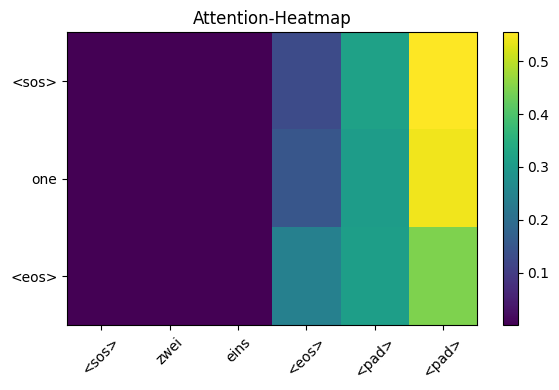

In [ ]:
def translate_with_attention(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs, attn = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        attn = attn.squeeze(0).cpu().numpy()  # [trg_len, src_len]

        pred_sentence = indices_to_sentence(preds, trg_itos)
        return pred_sentence, attn, src_ids

example_src = random.choice(pairs)[0]
pred_sentence, attn_matrix, src_ids = translate_with_attention(model_attn, example_src)

print("Quellsatz:", example_src)
print("Vorhersage:", pred_sentence)

src_tokens = [src_itos[i] for i in src_ids]
trg_tokens = [trg_itos[i] for i in encode_sentence(pred_sentence, trg_stoi)]

plt.figure(figsize=(6, 4))
plt.imshow(attn_matrix[:len(trg_tokens), :len(src_tokens)], aspect='auto')
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45)
plt.yticks(range(len(trg_tokens)), trg_tokens)
plt.colorbar()
plt.title("Attention-Heatmap")
plt.tight_layout()
plt.show()


## 7. Mini-HuggingFace Demo: “Großer” Transformer

In [ ]:
!pip install -q transformers sentencepiece

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-de-en"  # kleiner Übersetzungs-Transformer
tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

def translate_hf(text: str):
    inputs = tokenizer_hf(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_hf.generate(**inputs, max_new_tokens=50)
    return tokenizer_hf.batch_decode(outputs, skip_special_tokens=True)[0]

example_text = "Wir lernen heute Attention und Transformer."
print(translate_hf(example_text))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

We're learning attention and transformer today.


### Aufgabe (HuggingFace)

1. Ändern Sie `example_text` und testen Sie eigene Sätze.  
2. Probieren Sie (optional) ein anderes Modell aus, z.B.:
   - Summarization (`google/pegasus-xsum`)
   - Deutsch-Deutsch-Paraphrasierung o.ä.  

> Ziel: Gefühl dafür bekommen, wie Tokenizer + Transformer-Modell in der Praxis zusammenspielen.


## 8. Übungsaufgaben (Summary)

## Übungsaufgaben

1. **Eigene Sätze einbauen (Seq2Seq LSTM OHNE Attention)**  
   - Erweitern Sie die Liste `pairs` um eigene kleine Satzpaare (DE->EN oder sonstige Mapping-Aufgabe).  
   - Beobachten Sie, ob das Modell diese neuen Beispiele lernen kann.

2. **Hyperparameter-Experimente**  
   - Ändern Sie `EMB_DIM` und `HID_DIM`.  
   - Wie verändert sich die Trainingszeit und die Qualität der Vorhersagen?

3. **Hugging Face Exploration**  
   - Ändern Sie den Text in der HF-Demo und erläutern Sie in 2–3 Sätzen, was der Unterschied zwischen  
     unserem LSTM-Seq2Seq und dem vortrainierten Transformer-Modell ist (Datenmenge, Architektur, Qualität).
4. **Optionaler Task: Seq2Seq Forecasting (ohne Attention)**

Wir verwenden die bereits bekannte Encoder–Decoder Struktur aus der heutigen Vorlesung, aber diesmal nicht für Sprache, sondern für Zeitreihen.

**Ziel:**
Geben Sie die vergangenen n Werte in den Encoder und lassen Sie den Decoder die nächsten n Werte generieren.

**Hinweise:**

1. Entfernen Sie das Embedding — Zeitreihen sind numerisch.

2. src (Encoder Input) und trg (Decoder Target) sollen gleich lang sein.

3. \<sos> kann z.B. 0.0 sein oder ein learnable Parameter.

Der Decoder arbeitet autoregressiv:

\<sos> → y₁

y₁ → y₂

y₂ → y₃
… usw.

**Beispiel:**

Encoder Input:
x[t-9], x[t-8], …, x[t]

Decoder Output:
x[t+1], x[t+2], …, x[t+10]

# **Aufgabe:**
> Trainieren Sie das Modell auf Ihrem Datensatz und vergleichen Sie Seq2Seq LSTM Forecasting mit dem reinen LSTM aus der letzten Übung.
